# Module import

In [2]:
from netCDF4 import Dataset                             
import numpy as np            

import matplotlib.pyplot as plt           
import matplotlib.colors as mcolors              
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader

import sys
import torch 
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta

import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

In [3]:
sys.path.append("/home/users/mendrika/Object-Based-LSTMConv/notebooks/model/training")
from pancast import Core2MapModel

# Choose nowcast origin and lead time (in hour)

In [4]:
year = "2024"
month = "09"
day = "30"
hour = "13"
minute = "00"

# Ground truth 

In [5]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [6]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    
    nowcast_origin = {
        "year":   year,
        "month":  month,
        "day":    day,
        "hour":   hour,
        "minute": minute,
    }

    nowcast_lt = update_hour(nowcast_origin, hours_to_add=0, minutes_to_add=lead_time)["time"]

    path_core = f"/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{nowcast_lt['year']}/{nowcast_lt['month']}"
    file = f"{path_core}/{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    return Dataset(file, mode='r')["cores"]

In [7]:
y_min, y_max = 48, 2062
x_min, x_max = 81, 2267

In [8]:
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

In [9]:
lats = np.where(lats < -900, np.nan, lats)
lons = np.where(lons < -900, np.nan, lons)

lat_min = np.nanmin(lats)
lat_max = np.nanmax(lats)

lon_min = np.nanmin(lons)
lon_max = np.nanmax(lons)

print(lat_min, lat_max, lon_min, lon_max)

-39.91001 26.57356 -23.102037 79.549774


In [10]:
def load_zcast_input(year, month, day, hour, minute, lead_time):

    input_paths = [
        "/work/scratch-nopw2/mendrika/pancast/raw/inputs_t0",
        "/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/raw/inputs_t0",
    ]

    fname = f"input-{year}{month}{day}_{hour}{minute}.pt"

    for base in input_paths:
        core_input = f"{base}/{fname}"
        if os.path.exists(core_input):
            return torch.load(core_input)

    raise FileNotFoundError(
        f"ZCAST input not found in any known location: {fname}"
    )

In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
ENSEMBLE_DIR_T030 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min"
ENSEMBLE_DIR_T060 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min"
ENSEMBLE_DIR_T090 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t090min"
ENSEMBLE_DIR_T120 = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t120min"

In [13]:
def load_models(ensemble_dir):
    models = []
    for seed in sorted(os.listdir(ensemble_dir)):
        ckpt = os.path.join(ensemble_dir, seed, "lr7e-05/best-pancast.ckpt")
        if os.path.exists(ckpt):
            model = Core2MapModel.load_from_checkpoint(ckpt, map_location=DEVICE)
            model.eval().to(DEVICE)
            models.append(model)
            print(f"Loaded {ckpt}")
    return models

In [14]:
def ensemble_predict(models, x):
    preds = []
    with torch.no_grad():
        for model in models:
            pred = torch.sigmoid(model(x)).squeeze(0).squeeze(0)
            preds.append(pred)
    preds = torch.stack(preds)
    mean_pred = preds.mean(dim=0)
    var_pred  = preds.var(dim=0)
    return mean_pred, var_pred

In [15]:
models_t030 = load_models(ENSEMBLE_DIR_T030)
models_t060 = load_models(ENSEMBLE_DIR_T060)
models_t090 = load_models(ENSEMBLE_DIR_T090)
models_t120 = load_models(ENSEMBLE_DIR_T120)

Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed134/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed1998/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed2025/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed40/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t030min/seed676/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed134/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed1998/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed2025/lr7e-05/best-pancast.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/pancast/final/checkpoints/t060min/seed40/lr7e-05

In [16]:
SCALER_PATH = "/home/users/mendrika/Object-Based-LSTMConv/outputs/scaler-africa/scaler_realcores_online.pt"

MASK_COL_INDEX = 12
COLS_TO_SCALE = range(4, 12)

# load scaler
scaler = torch.load(SCALER_PATH, weights_only=False)
mean = np.asarray(scaler["mean"])
scale = np.asarray(scaler["scale"])

In [17]:
zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

In [18]:
try:
    # load one instance
    zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

    input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

    # remove batch dim for scaling
    X = input_tensor[0]

    # convert to numpy
    X_np = X.numpy()

    flat = X_np.reshape(-1, X_np.shape[-1])

    flat[:, COLS_TO_SCALE] = (flat[:, COLS_TO_SCALE] - mean) / scale

    X_scaled = torch.tensor(flat.reshape(X_np.shape), dtype=torch.float32)

    input_scaled = X_scaled.unsqueeze(0)

    mean_pred_t030, _ = ensemble_predict(models_t030, input_scaled.to(DEVICE))
    mean_pred_t060, _ = ensemble_predict(models_t060, input_scaled.to(DEVICE))
    mean_pred_t090, _ = ensemble_predict(models_t090, input_scaled.to(DEVICE))
    mean_pred_t120, _ = ensemble_predict(models_t120, input_scaled.to(DEVICE))

except:
    print("No data")

In [20]:
mean_pred_t030.shape

torch.Size([2015, 2187])

In [21]:
preds = {
    30: mean_pred_t030,
    60: mean_pred_t060,
    90: mean_pred_t090,
    120: mean_pred_t120
}

def gamma_boost(pred, gamma=2.0):
    pred = pred.copy()
    pred = np.clip(pred, 0.0, 1.0)
    return pred ** gamma


def rescale_after_threshold(pred, floor=0.05, eps=1e-6):
    pred = pred.copy()
    pred[pred < floor] = 0.0

    max_val = pred.max()
    if max_val > eps:
        pred = pred / max_val
    return pred


for lead in preds:

    pred = preds[lead].cpu().numpy()

    pred = rescale_after_threshold(pred, floor=0.1)

    pred = gamma_boost(pred, gamma=0.85)

    pred = np.ma.masked_where(pred < 0.05, pred)

    preds[lead] = pred

# Regridding

In [26]:
from scipy.spatial import cKDTree

valid = (lats > -900) & (lons > -900)

lat_min = lats[valid].min()
lat_max = lats[valid].max()
lon_min = lons[valid].min()
lon_max = lons[valid].max()

ny = nx = 512

lat_grid = np.linspace(lat_min, lat_max, ny)
lon_grid = np.linspace(lon_min, lon_max, nx)

lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

source_points = np.column_stack((lons[valid], lats[valid]))
target_points = np.column_stack((lon2d.ravel(), lat2d.ravel()))

tree = cKDTree(source_points)
dist, idx = tree.query(target_points)

np.save("msg_to_regular_idx.npy", idx)

regular_preds = {}

for lead, pred in preds.items():

    if hasattr(pred, "cpu"):
        pred = pred.cpu().numpy()

    values = pred[valid]

    reg = values[idx].reshape(ny, nx)

    regular_preds[lead] = reg

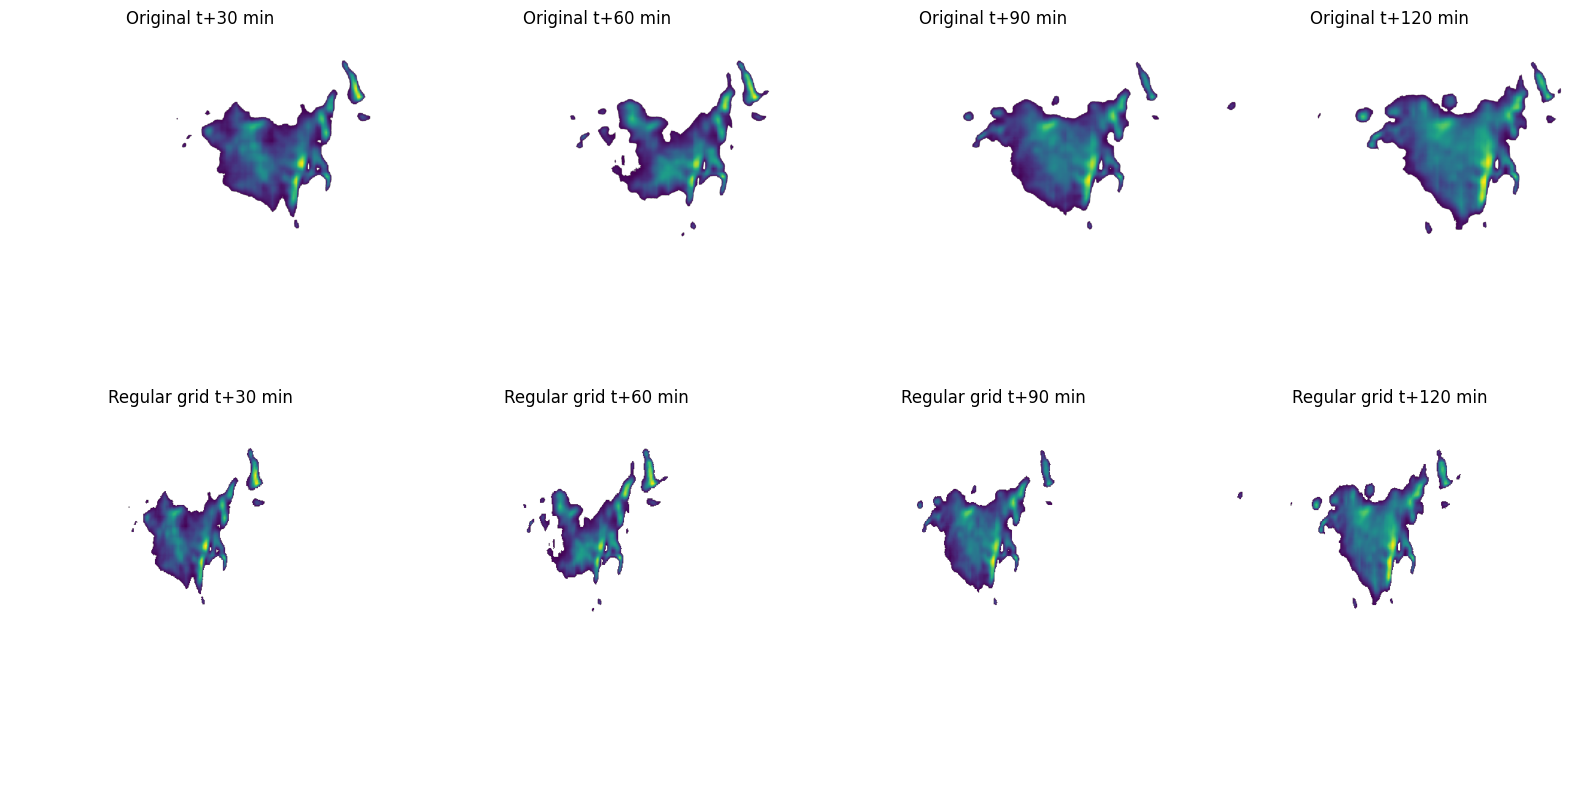

In [27]:
import matplotlib.pyplot as plt

leads = [30, 60, 90, 120]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, lead in enumerate(leads):

    # original
    ax = axes[0, i]
    ax.imshow(preds[lead], origin="lower")
    ax.set_title(f"Original t+{lead} min")
    ax.axis("off")

    # regular
    ax = axes[1, i]
    ax.imshow(regular_preds[lead], origin="lower")
    ax.set_title(f"Regular grid t+{lead} min")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
out_dir = "/home/users/mendrika/PANCAST/outputs/regular"
os.makedirs(out_dir, exist_ok=True)

for lead, data in regular_preds.items():

    plt.figure(figsize=(6,6), dpi=200)

    data = np.ma.masked_where(data == 0, data)

    plt.imshow(
        data,
        origin="lower",
        vmin=0,
        vmax=1
    )

    plt.axis("off")

    fname = f"pancast_t{lead:03d}.png"

    plt.savefig(
        os.path.join(out_dir, fname),
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

In [30]:
dx = lon_grid[1] - lon_grid[0]
dy = lat_grid[1] - lat_grid[0]

np.savez(
    os.path.join(out_dir, "grid_regular_512.npz"),
    lon2d=lon2d,
    lat2d=lat2d,
    lon_grid=lon_grid,
    lat_grid=lat_grid,
    dx=dx,
    dy=dy,
    lon_min=lon_grid.min(),
    lon_max=lon_grid.max(),
    lat_min=lat_grid.min(),
    lat_max=lat_grid.max()
)